# Benchmark water clusters: binding energies and relaxed geometries

Where the rsfff models land on the standard set of water-cluster minima, next to the numbers
published for MB-Pol and CMM. The clusters are the 25 in `data/kristina_clusters/all_clusters.xyz`
-- dimer through `(H2O)25`, several isomers each at n = 6, 8, 16 and 20.

Everything here reads one file, `data/kristina_clusters/benchmark_clusters.csv`, which
`scripts/build_benchmark_clusters_csv.py` builds by joining two sources row by row:

- the **published table**, transcribed by hand: q-AQUA, MB-Pol, CMM, wB97X-V and HIPPO binding
  energies, the reference binding energies, and the RMSD of each method's relaxed geometry to
  the reference minimum;
- the **rsfff models**, straight out of `scripts/optimize_clusters.py` run on
  `checkpoints/water_film/best.pt` (`rsfff`) and `checkpoints/water_film_large/best.pt`
  (`rsfff (large)`).

Two quantities, and they are the same two for every method, which is the only reason the
comparison is fair:

**binding energy** is `E_cluster - n * E_monomer` evaluated at *that method's own relaxed
geometry*, so monomer deformation is inside it. Errors are quoted **per water**, because a
20-mer has ten times the hydrogen bonds of a dimer and an unnormalized MAE would be a plot of
cluster size.

**RMSD** is the all-atom Kabsch RMSD between the method's relaxed geometry and the reference
minimum -- shape, not placement. A method can get the energy right on a structure it has moved
off the reference minimum, so the two figures are not redundant.

**One caveat on the transcription.** The published tables carry their own footers, and most of
them reproduce exactly from the values in the CSV: q-AQUA MAE/n 0.040, CMM 0.100, HIPPO 0.194,
and mean RMSD 0.026 / 0.046 / 0.017 for q-AQUA / MB-Pol / wB97X-V. Those agreements are what
validate the reference column. Two do not reproduce -- MB-Pol MAE/n comes out 0.109 against a
published 0.156, and wB97X-V 0.057 against 0.051 -- so either a value in one of those two
columns was mis-read off the table or the published footer was computed over something slightly
different. The MB-Pol *column* is good enough to plot against; its *aggregate* is unverified.

In [1]:
%matplotlib inline

import csv
import os
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np

# Resolve the repository root no matter where Jupyter starts the kernel.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

BENCHMARK_CSV = ROOT / "data/kristina_clusters/benchmark_clusters.csv"
FIGDIR = ROOT / "notebooks/figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.size": 9,
    "axes.edgecolor": "#b9bfcb",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#e6e9f0",
    "grid.linewidth": 0.7,
    "axes.axisbelow": True,
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.labelcolor": "#0b0b0b",
    "legend.frameon": False,
})

# The reference is not a series -- it is the axis everything else is measured against, so it
# gets ink rather than a hue. The four hues are a CVD-checked categorical set and each method
# also carries its own marker, so identity never rests on colour alone.
REFERENCE_INK = "#242934"
SURFACE = "#fcfcfb"
METHODS = [
    ("mbpol",      "MB-Pol",       "#2a78d6", "o"),
    ("cmm",        "CMM",          "#eb6834", "s"),
    ("film",       "rsfff",         "#1baf7a", "^"),
    ("film_large", "rsfff (large)", "#4a3aa7", "D"),
]

In [2]:
with open(BENCHMARK_CSV, newline="") as fh:
    rows = list(csv.DictReader(fh))

# `w6 Prism`, `w16 Boat a`, ... -- compact enough to sit on a rotated tick, and the same names
# the published table uses. The CSV keeps the repo's own label for each cluster in
# `repo_label`, which is how a row is traced back to a frame in `all_clusters.xyz`.
labels = [f"w{r['n_waters']} {r['isomer']}".rstrip() for r in rows]
n_waters = np.array([int(r["n_waters"]) for r in rows])
reference = np.array([float(r["energy_reference"]) for r in rows])
energy = {key: np.array([float(r[f"energy_{key}"]) for r in rows]) for key, *_ in METHODS}
rmsd = {key: np.array([float(r[f"rmsd_{key}"]) for r in rows]) for key, *_ in METHODS}
x = np.arange(len(rows))

mae_per_water = {key: float(np.abs((energy[key] - reference) / n_waters).mean()) for key, *_ in METHODS}
mean_rmsd = {key: float(rmsd[key].mean()) for key, *_ in METHODS}

print(f"{len(rows)} clusters, n = {n_waters.min()}-{n_waters.max()} waters")
print(f"{'method':>13}  {'MAE/n (kcal/mol)':>16}  {'mean RMSD (A)':>13}")
for key, name, *_ in METHODS:
    print(f"{name:>13}  {mae_per_water[key]:>16.3f}  {mean_rmsd[key]:>13.3f}")

25 clusters, n = 2-25 waters
       method  MAE/n (kcal/mol)  mean RMSD (A)
       MB-Pol             0.109          0.046
          CMM             0.100          0.033
        rsfff             0.435          0.093
rsfff (large)             0.246          0.080


In [3]:
def summary_bars(ax, values, title, xlabel):
    """Shared right-hand panel: one horizontal bar per method, best at the top."""
    order = sorted(METHODS, key=lambda m: values[m[0]])
    y = np.arange(len(order))
    ax.barh(y, [values[key] for key, *_ in order], height=0.55,
            color=[color for _key, _name, color, _marker in order],
            edgecolor=SURFACE, linewidth=1.5)
    for yi, (key, *_rest) in zip(y, order):
        ax.text(values[key] * 1.03, yi, f"{values[key]:.3f}", va="center",
                fontsize=8.5, color="#52514e")
    ax.set_yticks(y)
    ax.set_yticklabels([name for _key, name, *_ in order], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlim(0, max(values.values()) * 1.32)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.set_title(title, loc="left", fontsize=10)

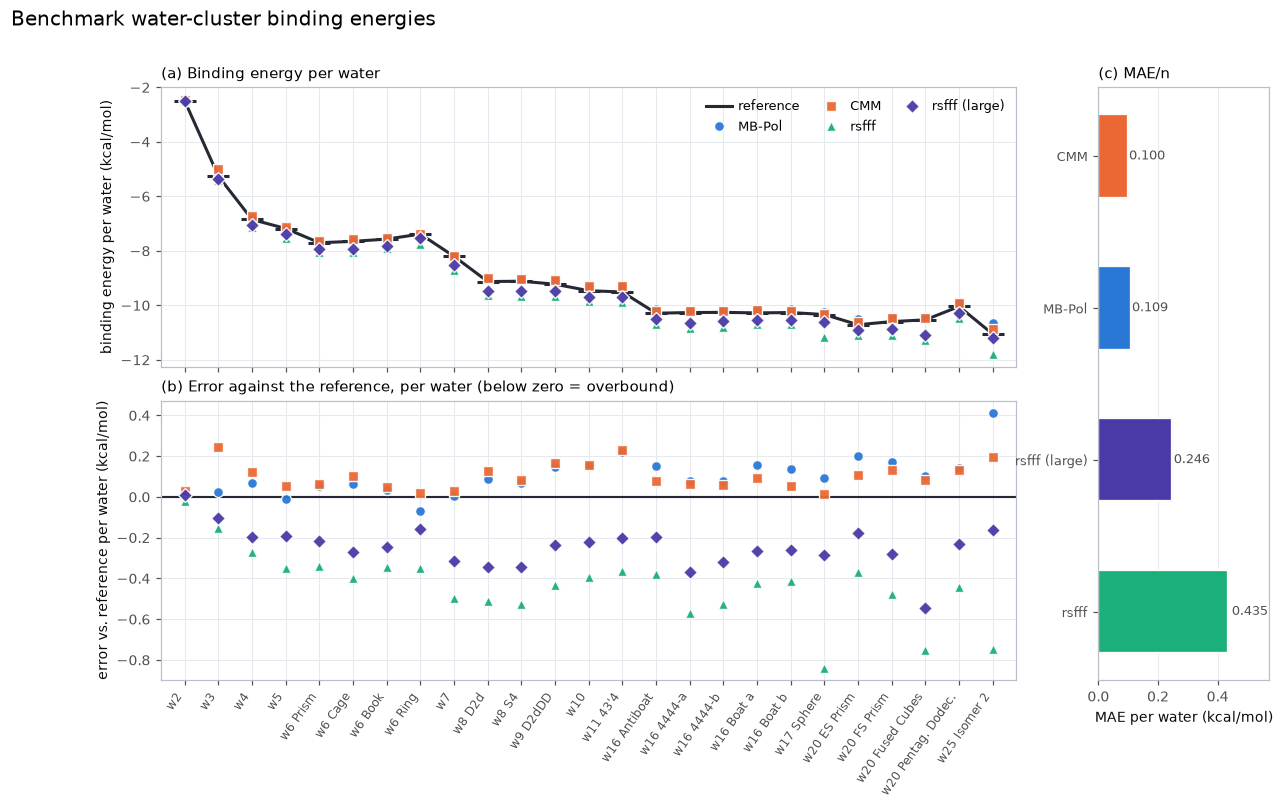

In [4]:
def energy_figure(path=None):
    """(a) the absolute curve for context, (b) the residual, (c) the aggregate.

    Panel (a) alone cannot show a 0.1 kcal/mol/water difference on a scale that runs from -2.5
    to -12; panel (b) alone loses the fact that the spread *between* isomers at fixed n is
    itself smaller than most of the errors. Both, sharing an x axis, say it in one read.
    """
    fig = plt.figure(figsize=(13.0, 7.0))
    gs = fig.add_gridspec(2, 2, width_ratios=[5.0, 1.0], hspace=0.12, wspace=0.16)
    ax_abs = fig.add_subplot(gs[0, 0])
    ax_err = fig.add_subplot(gs[1, 0])
    ax_mae = fig.add_subplot(gs[:, 1])

    ax_abs.plot(x, reference / n_waters, color=REFERENCE_INK, lw=2.0, zorder=1,
                marker="_", ms=14, mew=2.0, label="reference")
    for key, name, color, marker in METHODS:
        ax_abs.plot(x, energy[key] / n_waters, ls="none", marker=marker, ms=6.5, mew=0.9,
                    color=color, mec=SURFACE, alpha=0.95, label=name, zorder=2)
    ax_abs.set_ylabel("binding energy per water (kcal/mol)")
    ax_abs.set_xticks(x)
    ax_abs.set_xticklabels([])
    ax_abs.set_xlim(-0.7, len(rows) - 0.3)
    ax_abs.legend(ncol=3, loc="upper right", fontsize=8.5, columnspacing=1.4, handletextpad=0.5)
    ax_abs.set_title("(a) Binding energy per water", loc="left", fontsize=10)

    ax_err.axhline(0.0, color=REFERENCE_INK, lw=1.4, zorder=1)
    for key, name, color, marker in METHODS:
        ax_err.plot(x, (energy[key] - reference) / n_waters, ls="none", marker=marker, ms=6.5,
                    mew=0.9, color=color, mec=SURFACE, alpha=0.95, zorder=2)
    ax_err.set_ylabel("error vs. reference per water (kcal/mol)")
    ax_err.set_xticks(x)
    ax_err.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax_err.set_xlim(-0.7, len(rows) - 0.3)
    ax_err.set_title("(b) Error against the reference, per water (below zero = overbound)",
                     loc="left", fontsize=10)

    summary_bars(ax_mae, mae_per_water, "(c) MAE/n", "MAE per water (kcal/mol)")

    fig.suptitle("Benchmark water-cluster binding energies", x=0.02, ha="left", fontsize=13)
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = energy_figure(FIGDIR / "benchmark_clusters_energy.png")

Both rsfff models **overbind**, and they do it on every cluster past the dimer -- panel (b) is a
band below zero, not a scatter around it. That is a bias rather than noise, and it is the
cheaper of the two failures to have: the curve in panel (a) has the right shape, including the
ordering of the isomers within each n, and sits below the reference by a roughly constant
per-water amount. Retraining on larger clusters is doing what it was meant to, cutting MAE/n
from 0.435 to 0.246 -- a 43% reduction -- and shrinking the offset everywhere.

The offset does grow with cluster size, though, and this is the part worth watching. Mean
signed error per water goes from -0.34 at n <= 8 to -0.54 at n >= 16 for the small model, and
-0.22 to -0.28 for the large one. Something still scales with the number of hydrogen bonds
rather than with the number of waters. MB-Pol drifts the same way in the opposite direction
(+0.03 to +0.16); CMM is the one method here that is flat in n (+0.08 to +0.09), which is the
behaviour to aim at.

The worst individual clusters are not the biggest ones. `w17 Sphere` (-0.84 per water for the
small model) and `w20 Fused Cubes` (-0.75, and -0.55 for the large model) are the two outliers,
while `w25 Isomer 2` -- the largest cluster in the set -- is one of the large model's better
results at -0.16.

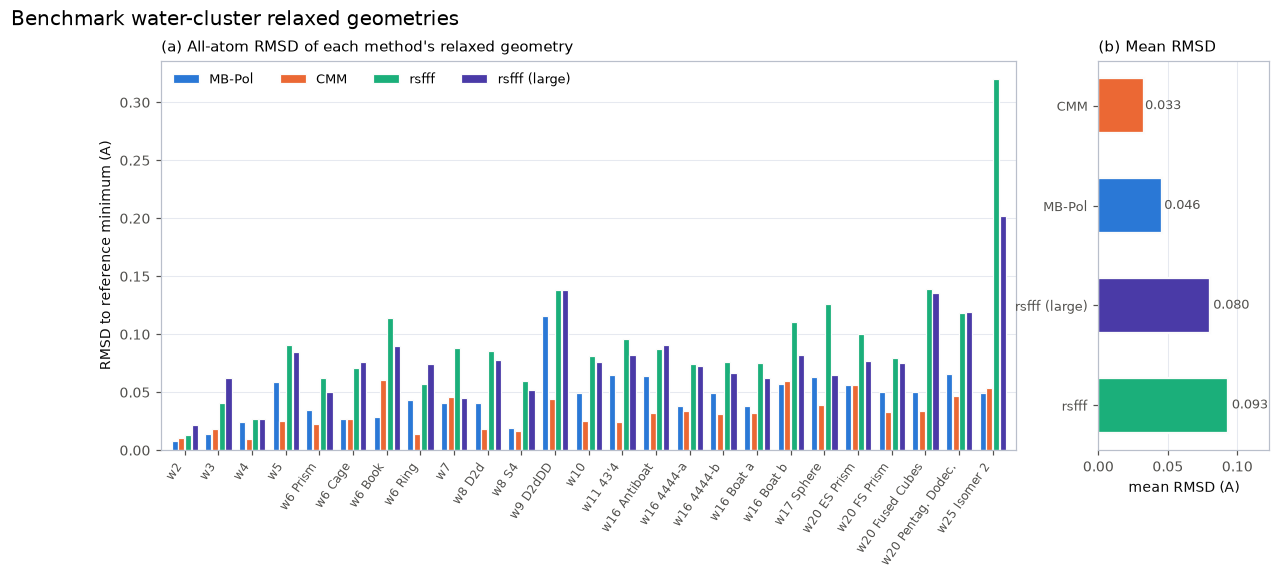

In [5]:
def rmsd_figure(path=None):
    """Grouped bars, linear scale on purpose.

    `w25 Isomer 2` sets the top of the axis and squashes everything else, and that is the
    honest picture -- it is the one cluster whose relaxed geometry genuinely moved, and a log
    axis would flatter it.
    """
    fig = plt.figure(figsize=(13.0, 4.6))
    gs = fig.add_gridspec(1, 2, width_ratios=[5.0, 1.0], wspace=0.16)
    ax = fig.add_subplot(gs[0, 0])
    ax_mean = fig.add_subplot(gs[0, 1])

    width = 0.2
    for i, (key, name, color, _marker) in enumerate(METHODS):
        offset = (i - (len(METHODS) - 1) / 2) * width
        ax.bar(x + offset, rmsd[key], width=width * 0.9, color=color,
               edgecolor=SURFACE, linewidth=0.8, label=name)
    ax.set_ylabel("RMSD to reference minimum (A)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax.set_xlim(-0.7, len(rows) - 0.3)
    ax.grid(axis="x", visible=False)
    ax.legend(ncol=4, loc="upper left", fontsize=8.5)
    ax.set_title("(a) All-atom RMSD of each method's relaxed geometry", loc="left", fontsize=10)

    summary_bars(ax_mean, mean_rmsd, "(b) Mean RMSD", "mean RMSD (A)")

    fig.suptitle("Benchmark water-cluster relaxed geometries", x=0.02, ha="left", fontsize=13)
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = rmsd_figure(FIGDIR / "benchmark_clusters_rmsd.png")

The geometry gap is narrower than the energy gap. The rsfff models relax to within 0.093 A
(small) and 0.080 A (large) of the reference minima on average, against 0.046 A for MB-Pol and
0.033 A for CMM -- a factor of two to three, where the energies were off by a factor of two to
four. The hydrogen-bond topology survives relaxation everywhere in the set; nothing here
rearranges into a different isomer.

The hard cases are mostly shared rather than model-specific. `w9 D2dDD` is the worst cluster for
q-AQUA (0.089) and one of the worst for MB-Pol (0.116) as well as for both rsfff models (0.138),
which says the minimum is flat rather than that the rsfff models are wrong about it.

`w25 Isomer 2` is the one place an rsfff model clearly moves further than everything else: 0.320 A
for the small model against 0.029-0.054 A for the published methods, with the large model
roughly half again better at 0.202 A. It is also the largest cluster, the one furthest outside
either model's training set, and the only structure whose relaxation energy in
`all_clusters_film_opt.csv` runs to ~10 kcal/mol.

In [6]:
# The per-cluster numbers behind both figures, for reading off a specific isomer.
header = f"{'cluster':<18}{'reference':>10}" + "".join(f"{name:>14}" for _k, name, *_ in METHODS)
print(header)
print("-" * len(header))
for i, label in enumerate(labels):
    line = f"{label:<18}{reference[i]:>10.2f}"
    for key, *_rest in METHODS:
        line += f"{energy[key][i]:>9.2f}{(energy[key][i] - reference[i]) / n_waters[i]:>+6.2f}"
    print(line)
print("\nenergies in kcal/mol; the small number beside each is that method's error per water")

cluster            reference        MB-Pol           CMM         rsfff rsfff (large)
------------------------------------------------------------------------------------
w2                     -4.99    -4.96 +0.02    -4.93 +0.03    -5.03 -0.02    -4.97 +0.01
w3                    -15.77   -15.69 +0.03   -15.03 +0.25   -16.23 -0.15   -16.08 -0.10
w4                    -27.39   -27.12 +0.07   -26.91 +0.12   -28.47 -0.27   -28.18 -0.20
w5                    -35.90   -35.94 -0.01   -35.63 +0.05   -37.65 -0.35   -36.85 -0.19
w6 Prism              -46.20   -45.87 +0.06   -45.83 +0.06   -48.22 -0.34   -47.50 -0.22
w6 Cage               -45.90   -45.51 +0.07   -45.29 +0.10   -48.29 -0.40   -47.53 -0.27
w6 Book               -45.40   -45.19 +0.04   -45.10 +0.05   -47.45 -0.34   -46.88 -0.25
w6 Ring               -44.30   -44.70 -0.07   -44.18 +0.02   -46.39 -0.35   -45.25 -0.16
w7                    -57.40   -57.37 +0.00   -57.20 +0.03   -60.86 -0.49   -59.59 -0.31
w8 D2d                -73.00 